In [ ]:
import math
import ast
import pandas as pd
import numpy as np
import ipynbname
import matplotlib.cm as cm
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from OLD.Deep_RTLO_QNewton_R1 import *
from Functions.Utils import *
from Functions.Utils_RTLO import *
from Functions.Graphs import *
from Functions.TedaGraphs import *
import optuna
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.samplers import RandomSampler
from optuna.exceptions import TrialPruned
import optuna.visualization as vis
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE

FileName = ipynbname.name()
study_dir = f'Optimization/{FileName}/'
out_path = f'Optimization/{FileName}/Optimization.csv'
study_dir = os.path.normpath(study_dir)
out_path = os.path.normpath(out_path)

os.makedirs(study_dir, exist_ok=True)

RS = pd.read_excel(r'Dataset\RS.xlsx')
#RS = exponential_moving_average_df(RS,0.25)
HI = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = HI['PC1'].values

def to_nearest_pow10(val):
    return 10 ** np.round(np.log10(val))

def SelSampler(mode='auto'):
    '''mode: auto, random,  tpe'''
    if mode == 'auto':
        sampler = None
    elif mode == 'tpe':
        sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=250)
    elif mode == 'random':
        sampler=RandomSampler()
    return sampler

In [ ]:
def euclidian_dist(x1,x2):
    return np.linalg.norm(x1 - x2,ord=None)

class DataCloud:
	N=0
	def __init__(self,x,h,ID,rho,m,nI=1,nR=1,nO=1,ηS=[0.1],tau=1,mode='past',act = 'tanh'):
		self.ID = ID
		self.track = [ID]
		self.merged = False
		self.merge = None
		self.n = 1
		self.dim = len(x)
		self.rho = rho
		self.m = m
		self.mean=x
		self.center=x
		self.meant=np.array(x).dot(np.array(x))
		self.ecc = np.array([])
		self.variance=0
		self.pertinency=1
		self.tipicality=1e-12
		self.nI = nI
		self.nR = nR
		self.nO = nO
		self.N1 = ηS[0]
		self.mode = mode
		self.tau = tau
		self.act = act
		self.rnn = RTLO(self.nI, self.nR, self.nO,
					[self.N1], self.tau, self.mode, self.act)
		self.x = [x]
		self.rul = np.array([])
		self.rulR = np.array([])
		self.rulM = []
		self.rulU = []
		self.rulL = []
		self.t = []
		self.t2 = []
		self.h = [h]
		self.vU = 0
		self.vM = 0
		self.V_ = np.array([])
		self.R_ = np.array([])
		self.R = 0
		self.V = 0
		self.Rmax = 0
		self.Recc = 0
		self.Vecc = 0
		self.Rref = 1
		self.Vref  = (math.pi ** (self.dim / 2)) / math.gamma((self.dim / 2) + 1) * (self.Rref ** self.dim)
		self.Vmax = 0
		self.Vnorm = 0
		self.Cnorm = 0
		self.xMax = x
		self.xMin = x
		self.xRef = x
		self.xIni = x
		self.sp = 0
		self.sp_hist = np.array([])
		self.sp_sum = 0
		self.cov = 1
		self.cov_hist = np.array([])
		self.V = 0
	
	def PrintParams(self):
		if self.ID != 'GM':
			print( f'Granule: G{self.ID} | Radius: {self.R:2.5f} | Volume {self.V:2.5f} | Coverage {self.cov:2.5f} | Specificity {self.sp:2.5f}')
		else:
			print( f'Granule: {self.ID} | Radius: {self.R:2.5f} | Volume {self.V:2.5f} | Coverage {self.cov:2.5f} | Specificity {self.sp:2.5f}')
		
		
	def AddDataClaud(self,x,t,store=False):
		self.n=2
		self.mean=(self.mean+x)/2
		self.meant=((self.meant)/2) + (x.dot(x))/2
		self.variance=self.meant-self.mean.dot(self.mean)
		if store:
			self.t.append(t)
			self.x.append(x)

	def UpdateDataCloud(self,n,mean,meant,variance,tipicality,t,x,store=False):
		self.n=n
		self.mean=mean
		self.meant=meant
		self.variance=variance
		self.tipicality=tipicality
		self.Recc = np.sqrt(self.variance * self.m**2)
		self.Vecc = (math.pi ** (self.dim / 2)) / math.gamma((self.dim / 2) + 1) * (self.Recc ** self.dim)

		if store:
			self.t.append(t)
			self.x.append(x)

	def AdjustBounds(self, x, k, density=False):
			dim = self.dim
			R = np.sqrt(self.variance*(self.m**2))
			self.R = R
			self.R_ = np.append(self.R_,R)
			self.V = (math.pi ** (dim / 2)) / math.gamma((dim / 2) + 1) * (self.R ** dim)



In [ ]:
class AutoCloud:
	def __init__(self,m,nI=1,nR=1,nO=1,ηS=[0.1],
			  tau=1,eol=0,ref=0,mode='past',act='tanh',st=0,end=0,
			  rho=0.003,wtaG=True,wtaP=True,store=True):
		
		self.rho = rho
		self.vSum = 0
		self.st = st
		self.mode = mode
		self.act = act
		self.end = end
		self.nI = nI
		self.nR = nR
		self.nO = nO
		self.N1 = ηS[0]
		self.tau = tau
		self.eol = eol
		self.store = store
		self.y = None
		self.g = 1
		self.gCreated = 0
		self.c= np.array([])
		self.alfa= np.array([0.0],dtype=float)
		self.intersection = np.zeros((1,1),dtype=int)
		self.listIntersection = np.zeros((1),dtype=int)
		self.matrixIntersection = np.zeros((1,1),dtype=int)
		self.relevanceList = np.zeros((1),dtype=int)
		self.classIndex = []
		self.k=1
		self.m = m
		self.cloud_activation = []
		self.aux = np.array([])
		self.DSIs = [np.array([]) for i in range(nI)]
		self.OffineGrnls = None

		self.eolX = 0
		self.HI = np.array([])
		self.DSI = np.array([])
		self.eolDSI = 0
		self.HIp = np.array([])
		self.cycleP=np.array([])

		self.t = np.array([])
		self.rulL = np.array([])
		self.rulP = np.array([])
		self.rulP2 = np.array([])
		self.rulU = np.array([])
		self.rulR = np.array([])
		self.ref = ref
		self.rulR2 = np.array([])
		self.rulR_Train = np.array([])
		self.lim = 160
		self.yP = np.array([])
		self.yR = np.array([])

		self.hiR = np.array([])
		self.hiP = np.array([])
		self.hiL = np.array([])
		self.hiU = np.array([])

		self.wMape_hi = 0
		self.wMape_rul = 0

		self.wape_RUL_hist = np.array([])
		self.wape_RUL = 0
		self.eRul_Sum = 0
		self.eRul_Diff = 0

		self.wape_HI_hist = np.array([])
		self.wape_HI = 0
		self.eHI_Sum = 0
		self.eHI_Diff = 0

		self.εP = []
		self.εR = []
		self.wtaG = wtaG
		self.wtaP = wtaP
		self.xR = 0
		self.xF = 0
		self.Dmax = 0

		self.sp = 0
		self.cov = 0
		self.sp_hist = np.array([])
		self.cov_hist = np.array([])
		self.V = 0

		self.dim = None
		self.gm = None
		self.Cnorm_gm = 1
		self.Vnorm_gm = 0
		self.mean_gm = 0
		self.meant_gm = 0
		self.var_gm = 0
		self.xMax_gm = None
		self.Rmax_gm = 0
		self.Vmax_gm = 0

	def HI_Granularity(self):
		
		for pR,pL,pU,pP in zip(self.hiR,self.hiL,self.hiU,self.hiP):
			rL, rU = pR*0.75, pR*1.25
			wPred = pU-pL
			wReal = rU-rL
			sp = max(0,1-wPred/wReal)
			self.sp_hist = np.append(self.sp_hist,sp)
			self.sp += sp
			if pP >= rL and pP <= rU:
				self.cov += 1
				self.cov_hist = np.append(self.cov_hist,1)
			else:
				self.cov_hist = np.append(self.cov_hist,0)
			#print(sp,self.cov)

		self.sp = self.sp/len(self.hiL)
		self.cov = self.cov/len(self.hiL)
		self.V = self.sp*self.cov
	
	def RUL_Granularity(self):
		
		for rulR,rulL,rulP,rulU in zip(self.rulR,self.rulL,self.rulP,self.rulU):
			rulRL, rulRU = 0.75*rulR, 1.25*rulR
			wPred = rulU-rulL
			wReal = rulRU-rulRL
			
			sp = max(0,1-wPred/wReal)
			self.sp_hist = np.append(self.sp_hist,sp)
			self.sp += sp
			#if rulRL < rulL and rulU<rulRU:
			if rulL >= rulRL and rulU<=rulRU:
				self.cov += 1
				self.cov_hist = np.append(self.cov_hist,1)
			else:
				self.cov_hist = np.append(self.cov_hist,0)
			#print(sp,self.cov)

		self.sp = self.sp/len(self.rulR)
		self.cov = self.cov/len(self.rulR)
		self.V = self.sp*self.cov

	def RUL_Granularity2(self):

		for cloud in self.c:
			
			for rulR,rulL,rulP,rulU in zip(cloud.rulR,cloud.rulL,cloud.rul,cloud.rulU):
				rulRL, rulRU = 0.75*rulR, 1.25*rulR
				wPred = rulU-rulL
				wReal = rulRU-rulRL
				
				sp = max(0,1-wPred/wReal)
				cloud.sp_hist = np.append(cloud.sp_hist,sp)
				cloud.sp += sp
				#if rulRL < rulL and rulU<rulRU:
				if rulL >= rulRL and rulU<=rulRU:
					cloud.cov += 1
					cloud.cov_hist = np.append(cloud.cov_hist,1)
				else:
					cloud.cov_hist = np.append(cloud.cov_hist,0)
				#print(sp,self.cov)

			cloud.sp = cloud.sp/len(cloud.rulR)
			cloud.cov = cloud.cov/len(cloud.rulR)
			cloud.V = cloud.sp*cloud.cov

	def WAPE_RUL(self):
		yR, yP, t = self.rulR[-1], self.rulP[-1], self.k**2
		self.eRul_Diff = np.abs(yR*t - yP*t) + self.eRul_Diff
		self.eRul_Sum = np.abs(yR*t) + self.eRul_Sum
		self.wape_RUL = self.eRul_Diff/self.eRul_Sum

		if self.store:
			self.wape_RUL_hist = np.append(self.wape_RUL_hist,self.wape_RUL)

	def WAPE_HI(self):
		yR, yP, t = self.hiR[-1], self.hiP[-1], self.k**2
		self.eHI_Diff = np.abs(yR*t - yP*t) + self.eHI_Diff
		self.eHI_Sum = np.abs(yR*t) + self.eHI_Sum
		self.wape_HI = self.eHI_Diff/self.eHI_Sum

		if self.store:
			self.wape_HI_hist = np.append(self.wape_HI_hist,self.wape_HI)

	def teda_WAPE(self):
		self.WAPE_RUL()
		self.WAPE_HI()

	def AdjustCloudMaster(self,t,x):
			"""
			Calculates a single bounding sphere that contains all input spheres.
			"""
			clouds = self.c
			# 1. Extract 6 extreme points from each sphere surface along main axes
			points = []
			axes = np.eye(len(self.c[0].mean))
			for cloud in clouds:
				for axis in axes:
					points.append(cloud.mean + axis * cloud.R)
					points.append(cloud.mean - axis * cloud.R)
			points = np.array(points)
	
			# 2. Ritter's Algorithm: Find initial sphere from most distant points
			# Pick arbitrary point p0, find furthest point p1, then furthest p2 from p1
			p1 = points[np.argmax(np.linalg.norm(points - points[0], axis=1))]
			p2 = points[np.argmax(np.linalg.norm(points - p1, axis=1))]
	
			# Initial candidate sphere spanning p1 and p2
			center = (p1 + p2) / 2.0
			radius = np.linalg.norm(p1 - p2) / 2.0
	
			# 3. Expand sphere to cover any outlying points
			for p in points:
				dist = np.linalg.norm(p - center)
				if dist > radius:
					# Shift center and grow radius to contain point 'p'
					new_radius = (radius + dist) / 2.0
					center = center + (p - center) * (new_radius - radius) / dist
					radius = new_radius
	
			# 4. Final verification pass against original full sphere geometries
			for cloud in clouds:
				dist = np.linalg.norm(cloud.mean - center)
				if dist + cloud.R > radius:
					# Adjust to encompass the entire sphere 's'
					diff = dist + cloud.R - radius
					direction = (center - cloud.mean) / dist if dist > 0 else np.array([1, 0, 0])
					center = center - direction * (diff / 2.0)
					radius += diff / 2.0
		
			
			dim = self.gm.dim
			self.gm.mean = center
			self.gm.R = radius
			self.gm.Rmax = radius
			self.gm.V = (math.pi ** (dim / 2)) / math.gamma((dim / 2) + 1) * (radius ** dim)
			self.gm.n = self.k
			if self.store:
				self.gm.t.append(t)
				if self.k > 1:
					self.gm.x.append(x)
					
	def CalculateSpCov(self):
		vec = []
		for cloud in self.c:
			cloud.cov = cloud.n/self.gm.n
			cloud.sp_sum += max(0,1-cloud.V/self.gm.V)
			cloud.sp = cloud.sp_sum/self.gm.n
			vec.append(cloud.sp)
		#print(vec)
	
	def CreateCloud(self,x,t,store=False):
		self.gCreated = self.gCreated + 1
		cloud = DataCloud(x,(self.k-1),self.gCreated,self.rho,self.m,self.nI,self.nR,self.nO,
					[self.N1],self.tau,self.mode, self.act)
		if store:
			cloud.t.append(self.k)
		self.c = np.append(self.c,cloud)

	def CloudOtimization(self):
		vec = np.array([])
		for cloud in self.c:
			cloud.sp = cloud.sp/(self.k-1)
			cloud.cov = cloud.cov/(self.k-1)
			cloud.v = cloud.sp * cloud.cov
			vec = np.append(vec, cloud.v)
		self.vSum = np.sum(vec)

	def Adapt(self,y,z):
		n = self.c[0].rnn.n
		self.HI = np.append(self.HI,z[n])
		self.hiR = np.append(self.hiR,z[n])
		for i,cloud in enumerate(self.c):
			if self.alfa[i] > 0:
				cloud.rnn.fit(y,z)
	
	def Predict(self,y,show=False):
		ws = self.alfa/np.sum(self.alfa)
		p = (np.array([w*cloud.rnn.Predict(y) for cloud,w in zip(self.c,ws)]))
		p = np.sum(p)
		return p
	
	def DefRnnParams(self, cloud):
		if len(self.c)>1:
			params = self.c[-2].rnn.ReturnParameters()
		if len(self.c)==1:
			params = self.c[-1].rnn.ReturnParameters()
		cloud.rnn.ReceiveParameters(params)

	def MergeCloudsRNN(self, c1, c2, c3):
		ps1 = c1.rnn.ReturnParameters()
		ps2 = c2.rnn.ReturnParameters()
		params = [(ps1[i]+ps2[i])/2 for i in range(len(ps2))]
		c3.rnn.ReceiveParameters(params)
		
	
	def PredictTS(self,X):
		xP = X.copy()
		
		pP = self.Predict(xP)
		self.HIp = np.append(self.HIp,pP)

		self.rulR = np.append(self.rulR,0)
		self.rulP = np.append(self.rulP,0)
		self.rulL = np.append(self.rulL,0)
		self.rulU = np.append(self.rulU,0)

		for cloud in self.c:
			cloud.rnn.Restore()
		return

	def RULSingle(self,X,lim=None,show=False):
			if lim==None:
				lim = 160
			xP = X.copy()
			predict = True
			Ruls = [0 for i in range(3)]
			CheckRuls = [True for i in range(3)]
			PredVals = np.zeros(3)
			cont = True
	
			while predict:
				#if self.wtaG==False and self.wtaP==True:
				if self.wtaP:
					self.alfa = np.where(self.alfa<np.max(self.alfa),0,self.alfa)
				ws = self.alfa/np.sum(self.alfa)
	
				Pred = [w*c.rnn.PredictSingle(xP,True) for w,c in zip(ws,self.c)]
	
				PredVal = sum(Pred)
				yP = PredVal
	
				if cont:
					self.hiP = np.append(self.hiP,yP)
					self.hiL = np.append(self.hiL,yP)
					self.hiU = np.append(self.hiU,yP)
					cont = False
	
				xP = np.delete(np.append(xP,yP),0)
	
				for j,_ in enumerate(Ruls):
					if CheckRuls[j]:
						Ruls[j] = Ruls[j] + 1
	
					if Ruls[j] > lim:
						CheckRuls[j] = False
						Ruls[j] = lim
	
				for j,_ in enumerate(CheckRuls):
					if PredVal <= self.eol:
						CheckRuls[j] = False
				
				if sum(CheckRuls)==0:
					break
						
			for cloud in self.c:
				cloud.rnn.Restore()
	
			if Ruls[2] < Ruls[1]:
				Ruls[2] = Ruls[1] 
			self.t = np.append(self.t,self.k - 2)
			self.rulR = np.append(self.rulR,self.ref - self.k)
			self.rulP = np.append(self.rulP,Ruls[1])
			self.rulL = np.append(self.rulL,Ruls[0])
			self.rulU = np.append(self.rulU,Ruls[2])
	
			for i,cloud in enumerate(self.c):
				if self.alfa[i] > 0:
					cloud.t2.append(self.k-2)
					cloud.rulR = np.append(cloud.rulR,self.ref - self.k)
					cloud.rul = np.append(cloud.rul,Ruls[1])
					cloud.rulL.append(Ruls[0])
					cloud.rulM.append(Ruls[1])
					cloud.rulU.append(Ruls[2])
	
	def RULInterv(self,X,lim=None,show=False):
		if lim==None:
			lim = 160
		xP,xL,xU = X.copy(),X.copy(),X.copy()
		predict = True
		Ruls = [0 for i in range(3)]
		CheckRuls = [True for i in range(3)]
		PredVals = np.zeros(3)
		cont = True

		while predict:
			if self.wtaG==False and self.wtaP==True:
				self.alfa = np.where(self.alfa<np.max(self.alfa),0,self.alfa)
			ws = self.alfa/np.sum(self.alfa)

			Pred = [w*c.rnn.PredictIntr(xP,xL,xU,self.rho,False) for w,c in zip(ws,self.c)]

			PredVals = sum(Pred)
			yL,yP,yU = PredVals

			if cont:
				self.hiP = np.append(self.hiP,yP)
				self.hiL = np.append(self.hiL,yL)
				self.hiU = np.append(self.hiU,yU)
				cont = False

			xP = np.delete(np.append(xP,yP),0)
			xL = np.delete(np.append(xL,yL),0)
			xU = np.delete(np.append(xU,yU),0)

			for j,_ in enumerate(Ruls):
				if CheckRuls[j]:
					Ruls[j] = Ruls[j] + 1

				if Ruls[j] > lim:
					CheckRuls[j] = False
					Ruls[j] = lim

			for j,_ in enumerate(CheckRuls):
				if PredVals[j] <= self.eol:
					CheckRuls[j] = False
			
			if sum(CheckRuls)==0:
				break
					
		for cloud in self.c:
			cloud.rnn.Restore()

		if Ruls[2] < Ruls[1]:
			Ruls[2] = Ruls[1] 
		self.t = np.append(self.t,self.k - 2)
		self.rulR = np.append(self.rulR,self.ref - self.k)
		self.rulP = np.append(self.rulP,Ruls[1])
		self.rulL = np.append(self.rulL,Ruls[0])
		self.rulU = np.append(self.rulU,Ruls[2])

		for i,cloud in enumerate(self.c):
			if self.alfa[i] > 0:
				cloud.t2.append(self.k-2)
				cloud.rulR = np.append(cloud.rulR,self.ref - self.k)
				cloud.rul = np.append(cloud.rul,Ruls[1])
				cloud.rulL.append(Ruls[0])
				cloud.rulM.append(Ruls[1])
				cloud.rulU.append(Ruls[2])

	def RUL_Prediction(self,X,mode='single',lim=None,show=False):
		if mode=='single':
			self.RULSingle(X,lim,show)
		elif mode=='interval':
			self.RULInterv(X,lim,show)
		else:
			raise ValueError("Modo inválido. Escolha 'single' ou 'interval'.")
		if self.k >2:
			self.teda_WAPE()

	def AddRUL(self):
		for cloud in self.cloud_activation:
			cloud.rul = np.append(cloud.rul,self.rulP[-1])
		self.cloud_activation = []
	
	def MergeClouds(self,X):
		i=0
		while(i<len(self.listIntersection)-1):
			merge=False
			j=i+1
			while(j<len(self.listIntersection)):
				if(self.listIntersection[i] == 1 and self.listIntersection[j] == 1):
					self.matrixIntersection[i,j] = self.matrixIntersection[i,j] + 1
				idI = self.c[i].ID
				idJ = self.c[j].ID
				xMinI = self.c[i].xMin
				xMinJ = self.c[j].xMin
				xMaxI = self.c[i].xMax
				xMaxJ = self.c[j].xMax
				meanI = self.c[i].mean
				meanJ = self.c[j].mean
				meantI = self.c[i].meant
				meantJ = self.c[j].meant
				nI = self.c[i].n
				nJ = self.c[j].n
				tipicalityI = self.c[i].tipicality
				tipicalityJ = self.c[j].tipicality
				trackI = self.c[i].track
				trackJ = self.c[j].track
				varianceI = self.c[i].variance
				varianceJ = self.c[j].variance
				rulLI = self.c[i].rulL
				rulLJ = self.c[j].rulL
				rulUI = self.c[i].rulU
				rulUJ = self.c[j].rulU
				rulMI = self.c[i].rulM
				rulMJ = self.c[j].rulM
				nIntersc = self.matrixIntersection[i,j]
				
				if (nIntersc > (nI - nIntersc) or nIntersc > (nJ - nIntersc)):
					
					merge = True
					self.gCreated = self.gCreated + 1
					n = int(nI + nJ - nIntersc)
					mean = ((nI * meanI) + (nJ * meanJ))/(nI + nJ)
					meant = ((nI * meantI) + (nJ * meantJ))/(nI + nJ)
					variance = ((nI - 1) * varianceI + (nJ - 1) * varianceJ)/(nI + nJ - 2)
					tipicality = ((nI*tipicalityI)+(nJ*tipicalityJ))/(nI + nJ)

					newCloud = DataCloud(X,self.k-1,self.gCreated,self.rho,self.m,self.nI,self.nR,self.nO,
									[self.N1,self.N2,self.N3],self.tau,self.mode, self.act)
					for id in trackI:
						newCloud.track.append(id)
					for id in trackJ:
						newCloud.track.append(id)
						
					newCloud.UpdateDataCloud(n,mean,meant,variance,tipicality,self.k,X)

					x = self.c[i].x + self.c[j].x
					t = self.c[i].t + self.c[j].t
					t2 = self.c[i].t2 + self.c[j].t2

					rulM = rulMI + rulMJ
					rulL = rulLI + rulLJ
					rulU = rulUI + rulUJ
					
					mat = np.array(list(zip(t,x)), dtype=object)
					col = mat[:, 0].astype(int) 
					_, index = np.unique(col, return_index=True)
					result = mat[np.sort(index)]
					t = result[:, 0].tolist()
					x = result[:, 1].tolist()

					#mat = np.array(list(zip(t2,rulL,rulM,rulU)), dtype=object)
					#col = mat[:, 0].astype(int) 
					#_, index = np.unique(col, return_index=True)
					#result = mat[np.sort(index)]
					#t2   = result[:, 0].tolist()
					#rulL = result[:, 1].tolist()
					#rulM = result[:, 2].tolist()
					#rulU = result[:, 3].tolist()
					if np.linalg.norm(newCloud.mean - self.c[j].xIni) > np.linalg.norm(newCloud.mean - self.c[i].xIni):
						newCloud.xIni = (self.c[j].xIni)
					else: 
						newCloud.xIni = (self.c[i].xIni)

					newCloud.x = x
					newCloud.xMax = 0.5*(self.c[i].xMax + self.c[j].xMax)
					newCloud.xMin = 0.5*(self.c[i].xMin + self.c[j].xMin)
					newCloud.t = t
					#newCloud.t2 = t2
					#newCloud.rulL = rulL
					#newCloud.rulM = rulM
					#newCloud.rulU = rulU
					#xMin = np.minimum(xMinI, xMinJ)
					#xMax = np.maximum(xMaxI, xMaxJ)
					#newCloud.xMin = xMin
					#newCloud.xMax = xMax	
					newCloud.AdjustBounds(X,self.k)
						
					self.MergeCloudsRNN(self.c[i],self.c[j],newCloud)
					newCloud.merge = f'G{self.gCreated}: G{idI}+G{idJ}'

					self.cloud_activation.append(newCloud)
					self.aux = np.append(self.aux,newCloud.ID)

					self.listIntersection = np.concatenate((self.listIntersection[0 : i], np.array([1]), self.listIntersection[i + 1 : j],self.listIntersection[j + 1 : np.size(self.listIntersection)]),axis=None)
					self.c = np.concatenate((self.c[0 : i ], np.array([newCloud]), self.c[i + 1 : j],self.c[j + 1 : np.size(self.c)]),axis=None)
					M0 = self.matrixIntersection
					M1=np.concatenate((M0[0 : i , :],np.zeros((1,len(M0))),M0[i + 1 : j, :],M0[j + 1 : len(M0), :]))
					M1=np.concatenate((M1[:, 0 : i ],np.zeros((len(M1),1)),M1[:, i+1 : j],M1[:, j+1 : len(M0)]),axis=1)
					col = (M0[:, i] + M0[:, j])*(M0[: , i]*M0[:, j] != 0)
					col = np.concatenate((col[0 : j], col[j + 1 : np.size(col)]))
					lin = (M0[i, :]+M0[j, :])*(M0[i, :]*M0[j, :] != 0)
					lin = np.concatenate((lin[ 0 : j], lin[j + 1 : np.size(lin)]))
					M1[:,i]=col
					M1[i,:]=lin
					M1[i, i + 1 : j] = M0[i, i + 1 : j] + M0[i + 1 : j, j].T;   
					self.matrixIntersection = M1

				j += 1
			if(merge): 
				i = 0
			else: i += 1

	def run(self,X):
		self.alfa = np.zeros((np.size(self.c)),dtype=float)
		self.listIntersection = np.zeros((np.size(self.c)),dtype=int)
		if self.k==1:
			self.xR = X
			self.CreateCloud(X,self.k,self.store)
			self.alfa = np.ones(1)
			self.gm = DataCloud(X,(self.k-1),'GM',self.rho,self.m,self.nI,self.nR,self.nO,
					[self.N1],self.tau,self.mode, self.act)

		elif self.k==2:
			self.c[0].Vref = self.gm.Vref
			self.c[0].AddDataClaud(X,self.k,self.store)
			v = self.c[0].variance
			n = self.c[0].n
			self.alfa = np.ones(1)
			self.c[0].AdjustBounds(X,self.k)
			
		elif self.k>=3:
			i=0
			createCloud = True
			params = [[] for l in range(len(self.c))]
			for i,cloud in enumerate(self.c):
				cloud.Vref = self.gm.Vref
				n = cloud.n +1
				m = ((n-1)/n)*cloud.mean + (1/n)*X
				mT = ((n-1)/n) * cloud.meant + (X.dot(X))/n
				v = mT-m.dot(m)
				ecc = ((1/n)+((m-X).T.dot(m-X))/(n*v))
				n_ecc = ((1/n)+((m-X).T.dot(m-X))/(n*v))/2
				n_tip = (1 - (((1/n)+((m-X).T.dot(m-X))/((n*v))-(1e-12))))/(self.k-2)
		
				if(n_ecc<=(self.m**2 +1)/(2*n)):
					
					createCloud= False
					params[i] = [n,m,mT,v,n_tip]
					self.alfa[i] = n_tip
					self.listIntersection[i] = 1
				else:
					self.alfa[i] = 0
					self.listIntersection[i] = 0
				i+=1

			if self.wtaG: 
				self.alfa = np.where(self.alfa<np.max(self.alfa),0,self.alfa)
				self.listIntersection = np.where(self.alfa>0,1,self.alfa)
			
			for i,cloud in enumerate(self.c):
				if self.alfa[i]>0:
					n,m,mT,v,n_tip = params[i]
					cloud.UpdateDataCloud(n,m,mT,v,n_tip,self.k,X,self.store)
					cloud.AdjustBounds(X,self.k)


			if(createCloud):
				self.CreateCloud(X,self.store)
				self.listIntersection = np.insert(self.listIntersection,i,1)
				self.matrixIntersection = np.pad(self.matrixIntersection, ((0,1),(0,1)), 'constant', constant_values=(0)) 
				self.c[-1].t.append(self.k)
				self.c[-1].R = 0
				
				self.DefRnnParams(self.c[-1])
				self.alfa = np.append(self.alfa,1)
			
			if not self.wtaG: 
				self.MergeClouds(X)

			self.CalculateSpCov()

		self.AdjustCloudMaster(self.k,X)
		self.cycleP = np.append(self.cycleP,self.st+self.k-1)
		self.rulR_Train = np.append(self.rulR_Train,self.end-self.k)
		self.k=self.k+1

In [ ]:
params =  {'nI': 3, 'nR': 3, 'nO': 3, 'N1': 0.1, 'N2': 0.0001, 'N3': 0.001,
            'τ': 23, 'mode': 'Ahead', 'act': 'tanh'}

nI,nR,nO,N1,N2,N3,τ,mode,act= list(params.values())
X, Y, Z = PrepareData(RS, HI, nX=nI, nY=nO, mY=0, nZ=1, mode='past')

teda=AutoCloud(m=2.5,nI=nI,nR=[nR],nO=nO,ηS=[N1],mode=mode,
               tau=τ,rho=0.01,eol=0.3,ref=len(sig)-nI,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])

teda.RUL_Granularity()
print(teda.wape_HI,teda.wape_RUL)
PlotDSI_3D_PLT(teda)
teda.c = np.append(teda.c,teda.gm)   
#PlotGranulesSpace(teda,w=700,h=700)

In [ ]:
print(xxx)

In [ ]:
df2 = []
nMax = 15
names = ['MAPE_RUL', 'MAPE_HI', 'm', 'nI', 'nR', 'nO', 'mO', 'N1','TAU','past/ahead','activation']
for i in range(5):
    print('iteration:',i+1)
    def objective(trial):
        m = trial.suggest_float('m', 2, 3.5,step=0.1)
        nI = trial.suggest_int('nI', 2, nMax) 
        n_layers = trial.suggest_int('n_layers', 1, 4)
        nR = [trial.suggest_int(f'nR_layer_{l}', 3, 64) for l in range(n_layers)]
        nO = trial.suggest_int('nO', 1, nMax) 
        mO = trial.suggest_int('mO', 0, nMax) 
        N1 = trial.suggest_float('N1', 1e-9, 1e-1,log=True)
        τ = trial.suggest_float('τ', 1, 50,log=True)
        mode = trial.suggest_categorical('mode', ['ahead'])  
        act = trial.suggest_categorical('act', ['tanh','relu'])  

        if mode == 'past':
            if nO > nI: raise TrialPruned()
        elif mode == 'ahead':
            if nI> nMax or nO> nMax: raise TrialPruned()
            elif mO > nI: raise TrialPruned()
            
        X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
        nI = len(Y[0])
            
        teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1],mode=mode,act=act,
                    tau=τ,rho=0.0,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
        for j,_ in enumerate(X[:]):
            teda.run(X[j])
            teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1)
            teda.Adapt(Y[j],Z[j])

            if j%25==0:
                if teda.wape_RUL > 0.4: raise TrialPruned()
                if teda.wape_HI  > 0.4: raise TrialPruned()

        if teda.wape_RUL > 0.25: raise TrialPruned()
        if teda.wape_HI  > 0.25: raise TrialPruned()
        
        return teda.wape_RUL, teda.wape_HI

    study = optuna.create_study(
        study_name="estudo_limpo_v3",
        directions=['minimize','minimize'],
        sampler=SelSampler(mode='random'))

    study.optimize(objective, n_trials=4000, timeout=900)
    trials = study.best_trials
    trials_errors = [list(trial.values) for trial in trials]
    trials_params = [list(trial.params.values()) for trial in trials]

    for trial in study.best_trials:
        p = trial.params
        nR_list = [p[f'nR_layer_{l}'] for l in range(p['n_layers'])]
        
        row = [trial.values[0],trial.values[1],p['m'],p['nI'],str(nR_list),p['nO'],p['mO'],p['N1'],p['τ'],p['mode'],p['act']]
        df2.append(row)

df2 = pd.DataFrame(df2, columns=names)

if os.path.isfile(out_path) and out_path.startswith(study_dir):
    df1 = pd.read_csv(out_path)
    df_stdy = pd.concat([df1, df2], ignore_index=True)

else: df_stdy = df2

df_stdy.to_csv(out_path, index=False)
opt_path = os.path.join(study_dir,f'opt_{len(os.listdir(study_dir))-1}.csv')
df2.to_csv(opt_path, index=False)


In [30]:
df_params = pd.read_csv(out_path)
df_params = pd.read_csv(opt_path)
#df_params = df_params[(df_params['MAPE_RUL'] <= 0.25) & (df_params['MAPE_HI'] <= 0.08)]
params_list = df_params.values[:,2:]
df_params

,MAPE_RUL,MAPE_HI,m,nI,nR,nO,mO,N1,TAU,past/ahead,activation
0,0.126585,0.218348,2.5,15,"[13, 58, 25, 29]",10,8,1.388775e-05,1.126272,ahead,tanh
1,0.187570,0.203131,2.2,7,"[48, 21, 62, 25]",15,1,2.090627e-06,6.752330,ahead,relu
2,0.197251,0.064582,2.5,9,[32],13,3,4.020682e-07,7.725461,ahead,tanh
3,0.120220,0.110358,2.1,5,"[59, 6]",9,0,2.389905e-05,5.877055,ahead,tanh


0.1972507626824501 0.0645823357949586


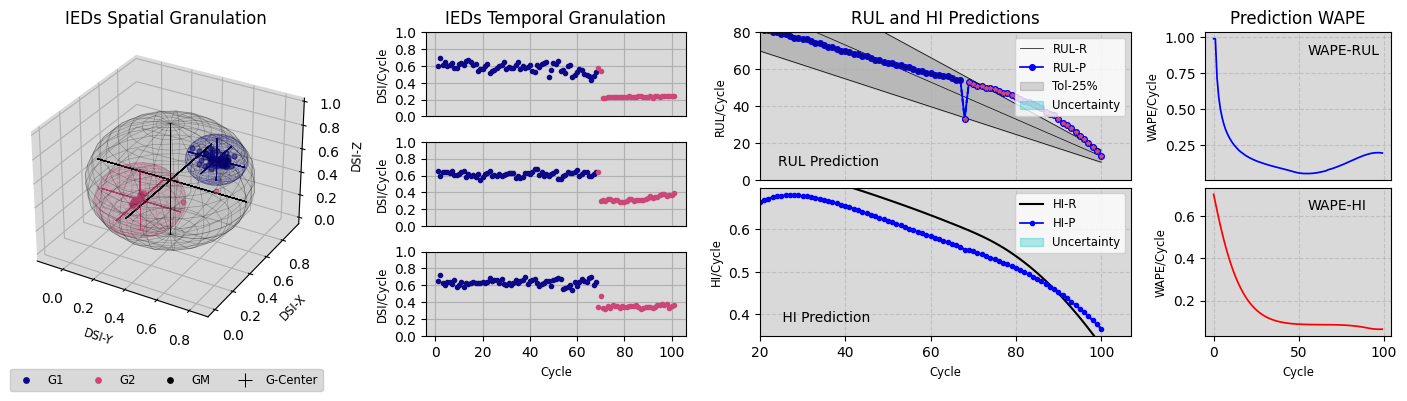

In [29]:
params_list = df_params.values[:,2:]

for i,params in enumerate(params_list):
    m,nI,nR,nO,mO,N1,τ,mode,act = params
    X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
    nI=len(Y[0])
    if isinstance(nR, str): nR = ast.literal_eval(nR)

    teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1],mode=mode,act=act,
                tau=τ,rho=0.03,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
    for j,_ in enumerate(X[:]):
        teda.run(X[j])
        teda.RUL_Prediction(Y[j],mode='single',lim=len(sig)-nI+1,show=False)
        teda.Adapt(Y[j],Z[j])
    print(teda.wape_RUL,teda.wape_HI)

    teda.c = np.append(teda.c,teda.gm)  
    #PlotSeriesPLY(ySeries=[teda.wape_HI_hist,teda.wape_RUL_hist])
    PlotDSI_3D_PLT(teda)

In [ ]:
m,nI,nR,nO,mO,N1,τ,mode,act = params_list[0]
X, Y, Z = PrepareData(RS, HI, nI, nO, mO, 1, mode)
nI = len(Y[0])
if isinstance(nR, str): nR = ast.literal_eval(nR)

teda=AutoCloud(m=m,nI=nI,nR=nR,nO=nO+mO,ηS=[N1,N2,N3],mode=mode,act=act,
               tau=τ,rho=0.01,eol=0.3,ref=len(sig)-nI+1,wtaG=True,wtaP=True) 
for j,_ in enumerate(X[:]):
    teda.run(X[j])
    teda.RUL_Prediction(Y[j],mode='interval',lim=len(sig)-nI+1,show=False)
    teda.Adapt(Y[j],Z[j])
teda.RUL_Granularity()
#teda.HI_Granularity()

print('cov',teda.cov,'sp',teda.sp,'cov * sp',teda.V,
      #teda.wape_RUL,teda.wape_HI
      )

teda.c = np.append(teda.c,teda.gm)  
PlotDSI_3D_PLT(teda)


In [ ]:
PlotSeriesPLY(ySeries=[teda.wape_RUL_hist,teda.wape_HI_hist],names=['rul','hi'])